In [2]:
from pathlib import Path

from PIL import Image
from transformers import Sam3Model, Sam3Processor
import requests
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
model_dir = repo_root / ".models" / "sam3_hf"

print(f"device: {device}")
print(f"model_dir exists: {model_dir.exists()} -> {model_dir}")

model = Sam3Model.from_pretrained(model_dir).to(device)
processor = Sam3Processor.from_pretrained(model_dir)

# Demo image that produces visible detections with the local SAM3 weights.
image_url = "http://images.cocodataset.org/val2017/000000077595.jpg"
response = requests.get(image_url, stream=True, timeout=30)
response.raise_for_status()
image = Image.open(response.raw).convert("RGB")

inputs = processor(images=image, text="ear", return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist(),
)[0]

print(f"Found {len(results['masks'])} objects")
print(f"boxes shape: {tuple(results['boxes'].shape)}")
print(f"scores shape: {tuple(results['scores'].shape)}")
results


device: cuda
model_dir exists: True -> C:\Users\Jiang\Documents\Mie_Postprocessing_Py\.models\sam3_hf


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 10637.68it/s]


Found 2 objects
boxes shape: (2, 4)
scores shape: (2,)


{'scores': tensor([0.9210, 0.9376], device='cuda:0'),
 'boxes': tensor([[402.1754,  90.1421, 459.6165, 156.3700],
         [301.0581,  85.5809, 359.3896, 160.2101]], device='cuda:0'),
 'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0')}

In [3]:
from PIL import Image

image_path = repo_root / "mask.png"
print(f"image_path exists: {image_path.exists()} -> {image_path}")

image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, text="mask", return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist(),
)[0]

print(f"Found {len(results['masks'])} objects")
print(f"boxes shape: {tuple(results['boxes'].shape)}")
print(f"scores shape: {tuple(results['scores'].shape)}")
results


image_path exists: True -> C:\Users\Jiang\Documents\Mie_Postprocessing_Py\mask.png
Found 0 objects
boxes shape: (0, 4)
scores shape: (0,)


{'scores': tensor([], device='cuda:0'),
 'boxes': tensor([], device='cuda:0', size=(0, 4)),
 'masks': tensor([], device='cuda:0', size=(0, 288, 288), dtype=torch.int64)}

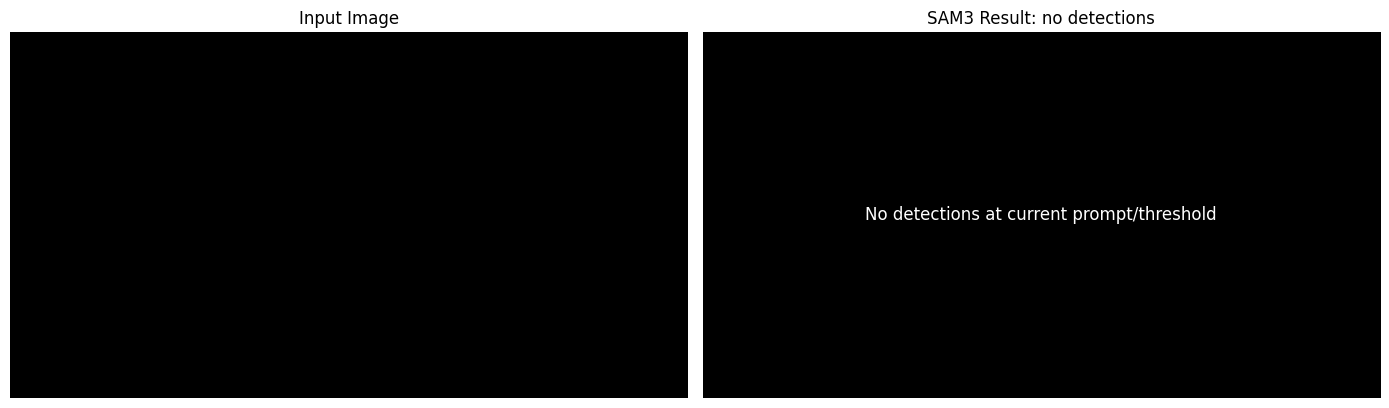

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

img = np.array(image)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(img)

num_masks = len(results["masks"])
if num_masks == 0:
    axes[1].set_title("SAM3 Result: no detections")
    axes[1].text(
        0.5,
        0.5,
        "No detections at current prompt/threshold",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        color="white",
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.6, pad=8),
    )
else:
    colors = plt.cm.tab10(np.linspace(0, 1, num_masks))
    for mask, box, score, color in zip(results["masks"], results["boxes"], results["scores"], colors):
        mask_np = mask.detach().cpu().numpy().astype(bool)
        color_rgb = np.array(color[:3])
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.float32)
        overlay[mask_np, :3] = color_rgb
        overlay[mask_np, 3] = 0.35
        axes[1].imshow(overlay)

        x0, y0, x1, y1 = box.detach().cpu().tolist()
        axes[1].add_patch(
            Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                fill=False,
                edgecolor=color_rgb,
                linewidth=2,
            )
        )
        axes[1].text(
            x0,
            max(y0 - 6, 0),
            f"score={float(score):.3f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
        )

    axes[1].set_title(f"SAM3 Result: {num_masks} detections")

axes[1].axis("off")
plt.tight_layout()
plt.show()
